In [1]:
import pandas as pd
import numpy as np

In [2]:
#carregar dado
df = pd.DataFrame(pd.read_csv('dados2025.csv'))
# Limpeza de dados 
#Arrumar valor de transação
df['valorTransacao'] = pd.to_numeric(df['valorTransacao']. 
                        str.replace('.', ''). #retira o . da casa de milhares
                        str.replace(',', '.'). #substitui , de centavos para .
                        str.replace('- ', '-') #substitui
)
df['dataTransacao'] = pd.to_datetime(df['dataTransacao']. 
                        str.replace('Sem informação', '01/01/2025'),
                        dayfirst=True
)
df = df[df['dataTransacao'].dt.year == 2025]
df = df.drop_duplicates()

In [9]:

#Detectar OutLiers atraves de ZScore > 3
df['z_score'] = df.groupby("unidadeGestora.orgaoMaximo.nome")["valorTransacao"].transform(lambda x:
                                                                                             (x-x.mean())*(1/ x.std()) 
                                                                                             if len(x)> 1 and x.std()> 0 
                                                                                             else 0 )
outliers = df[df['z_score']>3][['dataTransacao', 'unidadeGestora.orgaoMaximo.nome', 'portador.nome', 'valorTransacao', 'z_score']].sort_values(by='z_score', ascending=False)
print(outliers.head(10))

#Detectar Fracionamento de Despesa
frac = df.groupby(['dataTransacao','portador.nome', 'estabelecimento.nome']).size().reset_index(name='contagem')
frac = frac[frac['contagem']>5].sort_values(by='contagem', ascending=False)
frac = frac.drop(1) #transações sigilosas (sem data, nome e estabel)
# print(frac.head(10))



       dataTransacao                    unidadeGestora.orgaoMaximo.nome  \
139476    2025-06-19          Ministério da Justiça e Segurança Pública   
57400     2025-10-31                               Ministério da Defesa   
19517     2025-01-17                             Ministério da Educação   
142443    2025-09-14          Ministério da Justiça e Segurança Pública   
91325     2025-05-27                               Ministério da Defesa   
142442    2025-09-13          Ministério da Justiça e Segurança Pública   
142447    2025-09-18          Ministério da Justiça e Segurança Pública   
76832     2025-09-16  Ministério da Integração e do Desenvolvimento ...   
91645     2025-06-17                               Ministério da Defesa   
15245     2025-02-14                   Ministério do Trabalho e Emprego   

                         portador.nome  valorTransacao    z_score  
139476        JONAS PEREIRA DE FREITAS        72824.54  60.232275  
57400            MARCIO ALVES DA SILVA

In [10]:
# Flag IQR por órgão
def flag_iqr(group):
    Q1 = group['valorTransacao'].quantile(0.25)
    Q3 = group['valorTransacao'].quantile(0.75)
    IQR = Q3 - Q1
    group['flag_iqr'] = group['valorTransacao'] > Q3 + 1.5 * IQR
    return group

df = df.groupby("unidadeGestora.orgaoMaximo.nome", group_keys=False).apply(flag_iqr)


C:\Users\WinJoao\AppData\Local\Temp\ipykernel_15208\1365512786.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("unidadeGestora.orgaoMaximo.nome", group_keys=False).apply(flag_iqr)


In [11]:
frac = df.groupby(['dataTransacao','portador.nome','estabelecimento.nome']).size().reset_index(name='contagem')
df = df.merge(frac, on=['dataTransacao','portador.nome','estabelecimento.nome'], how='left')
df['flag_frac'] = df['contagem'] > 3

In [13]:
df['score_suspeito'] = df['flag_iqr'].astype(int) + df['flag_frac'].astype(int)


In [14]:
suspeitos = df[df['score_suspeito'] >= 2].sort_values('score_suspeito', ascending=False)
print(suspeitos.head(10))

       Unnamed: 0         id mesExtrato dataTransacao  valorTransacao  \
3631         3846  475220799    06/2025    2025-04-28         7381.00   
97432      104396  500798639    09/2025    2025-08-08         7500.00   
97430      104394  500798511    09/2025    2025-08-08         7500.00   
92972       99547  499623847    12/2025    2025-01-01         1794.15   
92846       99421  499615783    12/2025    2025-11-21         3762.60   
92069       98644  499566055    09/2025    2025-01-01         9340.00   
91466       98041  499527463    07/2025    2025-01-01         2652.00   
91465       98040  499527399    07/2025    2025-01-01         1249.95   
91440       98015  499525799    07/2025    2025-01-01         1028.00   
90670       97245  499476519    05/2025    2025-01-01         1358.00   

       tipoCartao.id  tipoCartao.codigo  \
3631               1                  1   
97432              1                  1   
97430              1                  1   
92972              1    

In [15]:
def iqr_outliers(group):
    Q1 = group['valorTransacao'].quantile(0.25)
    Q3 = group['valorTransacao'].quantile(0.75)
    IQR = Q3 - Q1
    return group[group['valorTransacao'] > Q3 + 1.5 * IQR]

outliers_iqr = df.groupby("unidadeGestora.orgaoMaximo.nome", group_keys=False).apply(iqr_outliers)

C:\Users\WinJoao\AppData\Local\Temp\ipykernel_15208\12598450.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outliers_iqr = df.groupby("unidadeGestora.orgaoMaximo.nome", group_keys=False).apply(iqr_outliers)


In [16]:
print(outliers_iqr)

       Unnamed: 0         id mesExtrato dataTransacao  valorTransacao  \
9810        10368  478827644    04/2025    2025-03-10         1510.00   
9811        10369  478827708    04/2025    2025-03-11         1510.00   
10281       11077  478852924    08/2025    2025-06-30         2110.00   
11161       11957  478881084    12/2025    2025-11-19         1085.09   
11319       12115  478886140    01/2026    2025-12-19         1026.00   
...           ...        ...        ...           ...             ...   
70867       76589  495332870    10/2025    2025-09-03       277106.46   
71265       76987  495358342    12/2025    2025-11-25       495176.64   
71267       76989  495358470    12/2025    2025-11-24       171015.33   
71855       77577  495396102    01/2026    2025-12-12       126922.25   
71856       77578  495396166    01/2026    2025-12-22      1530638.12   

       tipoCartao.id  tipoCartao.codigo  \
9810               1                  1   
9811               1                 

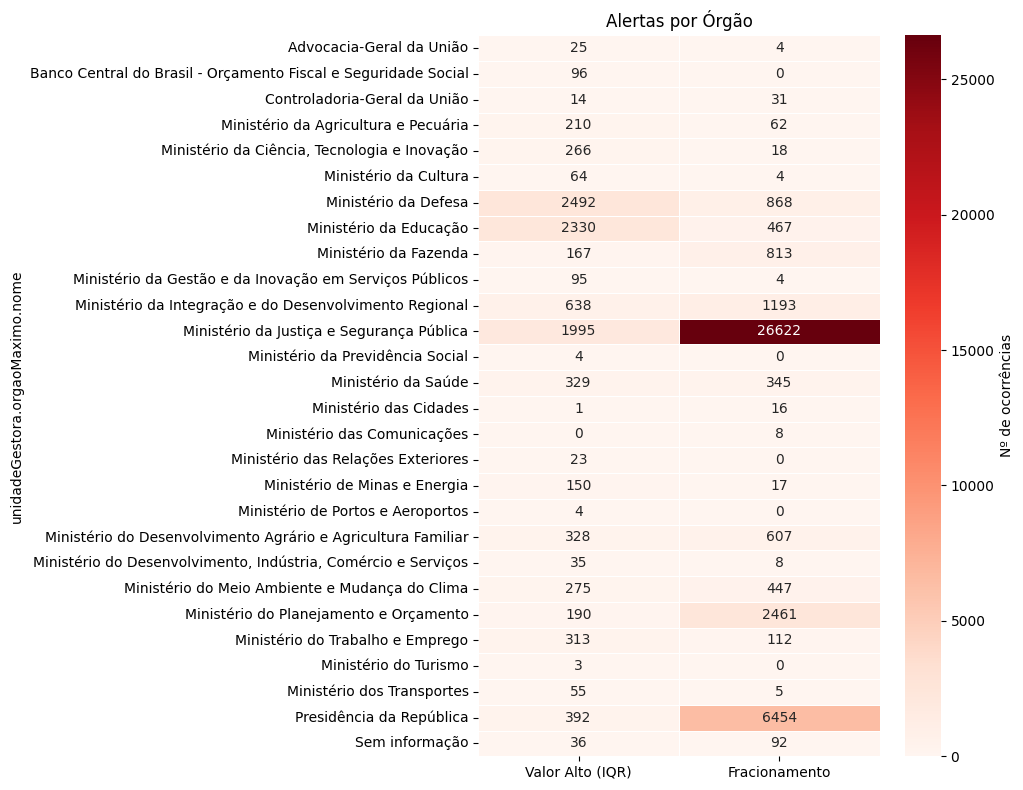

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

flag_cols = ['flag_iqr',  'flag_frac']
heat_flags = df.groupby('unidadeGestora.orgaoMaximo.nome')[flag_cols].sum()
heat_flags.columns = ['Valor Alto (IQR)', 'Fracionamento']
heat_flags = heat_flags[heat_flags.sum(axis=1) > 0]  # ignora sem alertas

plt.figure(figsize=(10, 8))
sns.heatmap(heat_flags, annot=True, fmt='.0f', cmap='Reds',
            linewidths=0.4, cbar_kws={'label': 'Nº de ocorrências'})
plt.title('Alertas por Órgão')
plt.tight_layout()
plt.show()

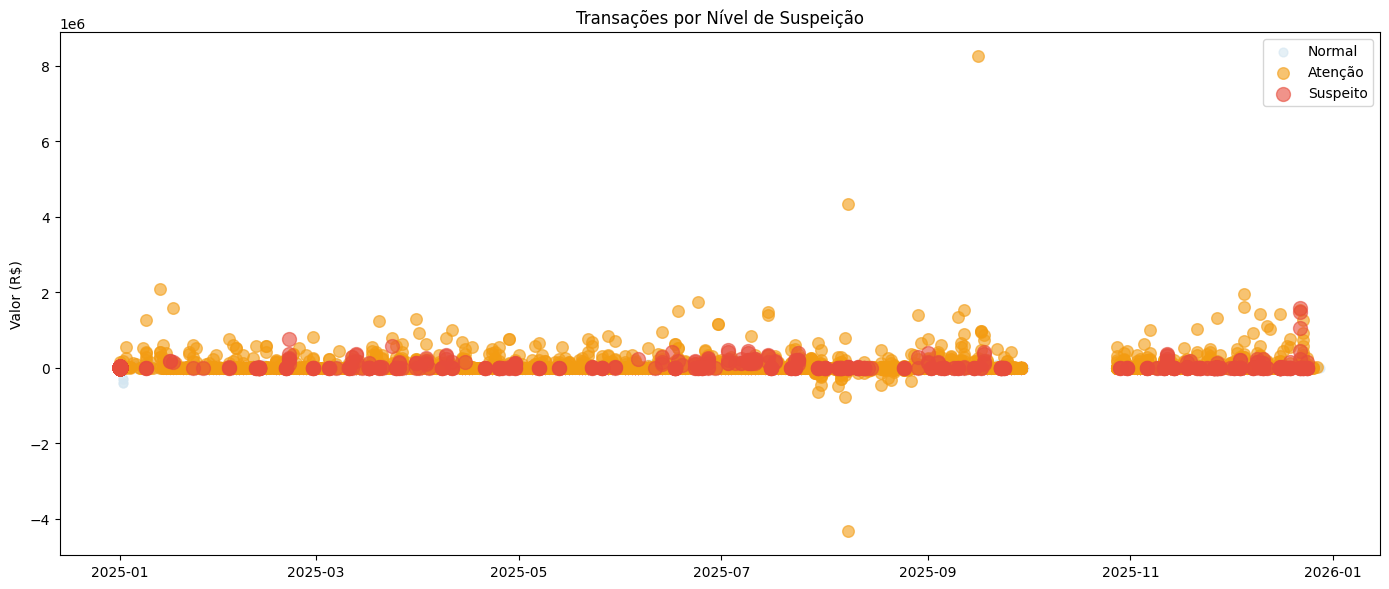

In [19]:
fig, ax = plt.subplots(figsize=(14, 6))

cores = {0: '#d4e6f1', 1: '#f39c12', 2: '#e74c3c', 3: '#7b241c'}
labels = {0: 'Normal', 1: 'Atenção', 2: 'Suspeito', 3: 'Crítico'}

for score in sorted(df['score_suspeito'].unique()):
    sub = df[df['score_suspeito'] == score]
    ax.scatter(sub['dataTransacao'], sub['valorTransacao'],
               c=cores[score], label=labels[score],
               alpha=0.6, s=40 + score * 30)

ax.set_title('Transações por Nível de Suspeição')
ax.set_ylabel('Valor (R$)')
ax.legend()
plt.tight_layout()
plt.show()

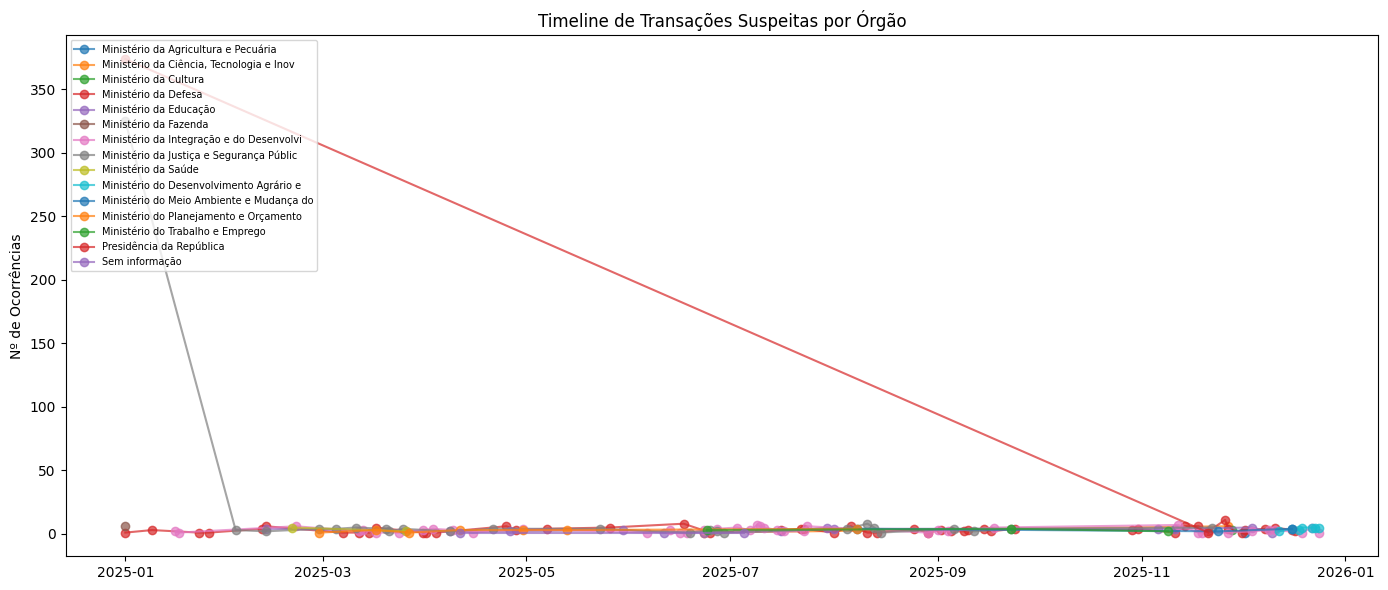

In [20]:
timeline = (df[df['score_suspeito'] >= 2]
            .groupby(['dataTransacao', 'unidadeGestora.orgaoMaximo.nome'])
            .size()
            .reset_index(name='ocorrencias'))

fig, ax = plt.subplots(figsize=(14, 6))
for orgao, grupo in timeline.groupby('unidadeGestora.orgaoMaximo.nome'):
    ax.plot(grupo['dataTransacao'], grupo['ocorrencias'],
            marker='o', label=orgao[:40], alpha=0.7)

ax.set_title('Timeline de Transações Suspeitas por Órgão')
ax.set_ylabel('Nº de Ocorrências')
ax.legend(fontsize=7, loc='upper left')
plt.tight_layout()
plt.show()